In [2]:
%matplotlib ipympl

  0%|          | 0/241 [00:00<?, ?it/s]

100%|██████████| 241/241 [00:03<00:00, 79.41it/s]


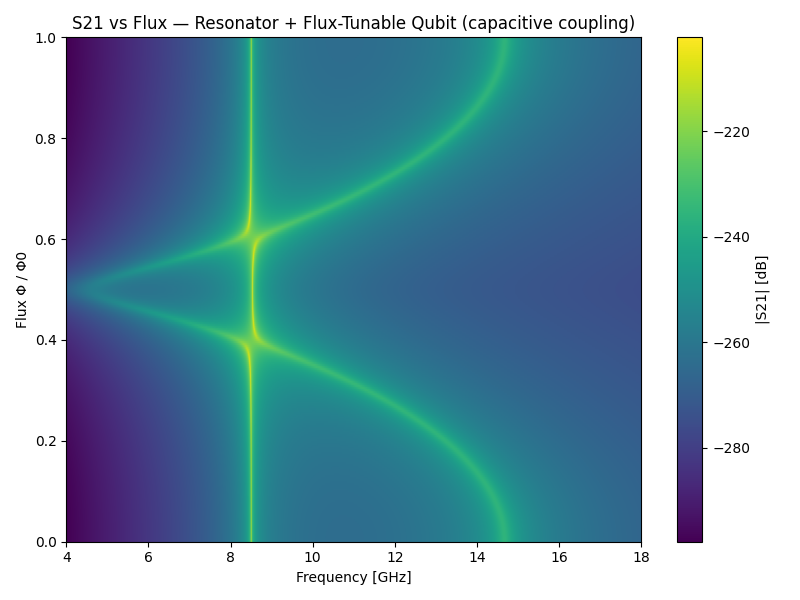

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

###############################################################################
# CONSTANTS
###############################################################################
Phi0 = 2.067833848e-15


###############################################################################
# SQUID EFFECTIVE PARAMETERS
###############################################################################

def squid_EJ_eff(EJ, d, Phi_ext):
    EJ1 = EJ*(1+d)
    EJ2 = EJ*(1-d)
    return np.sqrt(EJ1**2 + EJ2**2 + 2*EJ1*EJ2*np.cos(2*np.pi*Phi_ext/Phi0))

def squid_LJ(EJ_eff):
    return Phi0**2/(4*np.pi**2 * EJ_eff)

def squid_CJ(CJ):
    return 2*CJ


###############################################################################
# BUILD: Resonator + Qubit + Capacitive coupling
###############################################################################
def build_res_qubit_capacitive(
    Lr, Cr, Lq0, Cq,
    Cin, Ccoup,
    R, EJ, d, Phi_ext
):
    """
    nodes:
        0 = feedline port
        1 = resonator
        2 = qubit
    """

    # Flux-tuned qubit inductance
    EJ_eff = squid_EJ_eff(EJ, d, Phi_ext)
    Lq = squid_LJ(EJ_eff)
    Cq_eff = squid_CJ(Cq)

    n = 3
    K = np.zeros((n,n))
    C = np.zeros((n,n))
    G = np.zeros((n,n))

    # -------------------------------------------------------
    # Resonator inductance Lr (node1 to ground)
    # -------------------------------------------------------
    K[1,1] += 1/Lr

    # -------------------------------------------------------
    # Qubit inductance Lq(Φ) (node2 to ground)
    # -------------------------------------------------------
    K[2,2] += 1/Lq

    # -------------------------------------------------------
    # Shunt capacitances
    # -------------------------------------------------------
    C[1,1] += Cr + Cin        # resonator shunt + feedline Cin
    C[2,2] += Cq_eff          # qubit shunt

    # feedline-series capacitor Cin between node0 and node1
    C[0,0] += Cin
    C[0,1] -= Cin
    C[1,0] -= Cin

    # -------------------------------------------------------
    # Capacitive coupling between resonator (1) and qubit (2)
    # -------------------------------------------------------
    C[1,1] += Ccoup
    C[2,2] += Ccoup
    C[1,2] -= Ccoup
    C[2,1] -= Ccoup

    # -------------------------------------------------------
    # Feedline loss
    # -------------------------------------------------------
    G[0,0] = 1/R

    return K, C, G, Lq, Cq_eff

from scipy.constants import hbar, e
###############################################################################
# UNIVERSAL S21 SOLVER (your code)
###############################################################################
def s21_lossy(K, C, G, Cin, R, freqs, kappa_i, gamma_i):
    """
    Adds internal losses to:
        node 1 = resonator:  kappa_i
        node 2 = qubit:      gamma_i
    """

    n = C.shape[0]
    S = []

    for f in freqs:
        w = 2*np.pi*f

        # copy G each iteration (never modify input)
        G_eff = G.copy()

        # Add internal loss conductances:
        # physically, G has units of siemens (Ohm^-1)
        # damping term is (i*ω)*G in the equations.
        G_eff[1,1] += kappa_i / w       # resonator intrinsic loss
        G_eff[2,2] += gamma_i / w       # qubit intrinsic loss

        # Standard solve
        b = np.zeros(n)
        b[0] = 1/R

        M = K - w*w*C + 1j*w*G_eff
        phi = np.linalg.solve(M, b)

        S.append(phi[2])  # measure at resonator node (or phi[-1] if you want qubit node)

    return np.array(S)

# TODO WHICH NODE????

def s21(K,C,G,C_in,R,freqs):
    n = C.shape[0]
    S = []
    b = np.zeros(n)
    b[0] = 1/R
    for f in freqs:
        w = 2*np.pi*f
        M = K - w*w*C + 1j*w*G
        phi = np.linalg.solve(M, b)
        S.append(phi[1])
        # S.append(phi[-1])   # read at "end" node = qubit node (can also use node1)
    return np.array(S)

###############################################################################
# SIMULATION PARAMETERS
###############################################################################

# Target resonator frequency ~9 GHz
fr = 9e9
Cr = 60e-15
Lr = 1/((2*np.pi*fr)**2 * Cr)

# Target qubit frequencies 15 → 5 GHz
f_max = 15e9
Cq = 50e-15
Lq_max = 1/((2*np.pi*f_max)**2 * Cq)
# Convert to EJ so that flux tunes inductance correctly
EJ = Phi0**2/(4*np.pi**2 * Lq_max)
d  = 0.1

# Capacitive coupling strengths
Cin   = 2e-15       # feedline → resonator
Ccoup = 5e-15       # resonator ↔ qubit

# Feedline impedance
R = 50.0

# Frequency sweep
fspan = np.linspace(4e9, 18e9, 2000)

# Flux sweep
Phi_values = np.linspace(0, 1.0*Phi0, 241)

# Storage
S21_flux = np.zeros((len(Phi_values), len(fspan)), dtype=complex)


###############################################################################
# MAIN SIMULATION LOOP
###############################################################################
for i, Phi in enumerate(tqdm(Phi_values)):

    K, C, G, Lq_eff, Cq_eff = build_res_qubit_capacitive(
        Lr, Cr, Lq_max, Cq,
        Cin, Ccoup,
        R, EJ, d, Phi
    )

    kappa_i = 2*np.pi*1e3
    gamma_i = 2*np.pi*2e6

    S21_flux[i,:] = s21_lossy(
        K, C, G,
        Cin, R,
        fspan,
        kappa_i=kappa_i,
        gamma_i=gamma_i
    )


    # S21_flux[i,:] = s21(K, C, G, Cin, R, fspan)


###############################################################################
# PLOT
###############################################################################
plt.figure(figsize=(8,6))
extent = [fspan[0]/1e9, fspan[-1]/1e9, 0, 1]

plt.imshow(
    20*np.log10(np.abs(S21_flux)),
    aspect='auto',
    origin='lower',
    extent=extent,
    cmap='viridis'
)

plt.colorbar(label='|S21| [dB]')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Φ / Φ0')
plt.title("S21 vs Flux — Resonator + Flux-Tunable Qubit (capacitive coupling)")
plt.tight_layout()
plt.show()
